<a href="https://colab.research.google.com/github/jurados/alercehackton2026/blob/jurados/LSST_Candidates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
%%capture
!pip install alerce
!pip install pyvo

In [4]:
from alerce.core import Alerce
import pyvo as vo

In [5]:
alerce_client = Alerce()
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

In [6]:
tid = 1

In [7]:
n_objs = 200
n_det_min = 10
classifier_id = 1
class_id = 0 # SN

query = '''
SELECT TOP %d
    obj.*,
    prob.*
FROM
    alerce_tap.object AS obj
JOIN
    alerce_tap.probability AS prob
ON
    obj.oid = prob.oid
    AND obj.sid = prob.sid
WHERE
    obj.n_det >= %d
    AND prob.classifier_id = %d
    AND prob.class_id = %d
    AND prob.ranking = 1
ORDER BY prob.probability DESC
''' % (n_objs, n_det_min,
       classifier_id, class_id)
df_objs = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'lastmjd_']
df_objs.drop(columns=cols, inplace=True)
df_objs.to_csv("lsst_sn_candidates.csv", index=False)

In [8]:
df_objs

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date,classifier_id,classifier_version,class_id,probability,ranking
0,313765480543813793,1,1,60.558698,-49.059296,1.171559e-05,1.301392e-05,61004.301777,61095.089168,90.787391,20,190,0,2026-02-13,2026-02-24,1,201,0,0.997090,1
1,170032924022800424,1,1,186.228824,7.444803,4.080487e-06,3.929570e-06,61090.251692,61095.215152,4.963460,17,173,0,2026-02-20,2026-02-24,1,201,0,0.996842,1
2,313897384074018915,1,1,63.588264,-47.710480,1.767983e-05,1.785153e-05,61034.161767,61094.112531,59.950765,10,119,0,2026-02-13,2026-02-24,1,201,0,0.996777,1
3,313897384103379107,1,1,63.960148,-48.973827,2.329036e-05,2.255245e-05,61034.161767,61095.088734,60.926967,15,149,0,2026-02-13,2026-02-24,1,201,0,0.996365,1
4,313893023122980956,1,1,62.081009,-46.931759,2.830006e-07,2.768487e-07,61033.284793,61095.094861,61.810069,150,184,0,2026-02-13,2026-02-24,1,201,0,0.995795,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,313703905063601134,1,1,64.311151,-49.093889,9.618325e-06,1.133084e-05,60990.326391,61095.091331,104.764941,31,152,0,2026-02-13,2026-02-24,1,201,0,0.936846,1
196,313928193955332182,1,1,54.073448,-26.738356,1.626988e-07,1.676622e-07,61041.220126,61107.029563,65.809437,23,5,0,2026-02-13,2026-03-08,1,201,0,0.936161,1
197,313871015036846268,1,1,61.165461,-47.637616,2.854747e-07,2.929702e-07,61028.328577,61095.094861,66.766284,109,199,0,2026-02-13,2026-02-24,1,201,0,0.936049,1
198,170028529948297353,1,1,185.561397,6.717507,2.249719e-07,2.309306e-07,61090.258188,61095.218546,4.960358,120,227,0,2026-02-19,2026-02-24,1,201,0,0.934816,1


In [9]:
sid = 1
query = """
SELECT
    det.*,
    lsst_det.*
FROM
    alerce_tap.detection AS det
JOIN
    alerce_tap.lsst_detection AS lsst_det
ON
    det.oid = lsst_det.oid
    AND det.sid = lsst_det.sid
    AND det.measurement_id = lsst_det.measurement_id
WHERE
    det.sid = %d
    AND lsst_det.oid IN (%s)
""" % (sid, ','.join(map(str, df_objs.oid.values)))
df_aux = alerce_tap.search(query).to_table().to_pandas()

In [10]:
df_aux.columns

Index(['oid', 'sid', 'measurement_id', 'mjd', 'ra', 'dec', 'band',
       'created_date', 'oid_', 'sid_',
       ...
       'pixelflags_suspectcenter', 'pixelflags_streak',
       'pixelflags_streakcenter', 'pixelflags_injected',
       'pixelflags_injectedcenter', 'pixelflags_injected_template',
       'pixelflags_injected_templatecenter', 'glint_trail', 'has_stamp',
       'created_date_'],
      dtype='object', length=106)

In [11]:
#df_aux = df_aux[['oid','mjd', 'band', 'psfflux', 'psffluxerr', 'scienceflux', 'sciencefluxerr']]

In [12]:
df_aux

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,oid_,sid_,...,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,created_date_
0,170019696272736349,1,170019696272736349,61088.098045,61.497105,-49.245784,2,2026-02-19,170019696272736349,1,...,False,False,False,False,False,False,False,False,True,2026-02-19
1,170019696272736349,1,170028485813731360,61090.048021,61.497129,-49.245774,3,2026-02-19,170019696272736349,1,...,False,False,False,False,False,False,False,False,True,2026-02-19
2,170019696272736349,1,170028486077972623,61090.053112,61.497117,-49.245780,3,2026-02-19,170019696272736349,1,...,False,False,False,False,False,False,False,False,True,2026-02-19
3,170019696272736349,1,170028486452838484,61090.054409,61.497095,-49.245780,3,2026-02-19,170019696272736349,1,...,False,False,False,False,False,False,False,False,True,2026-02-19
4,170019696272736349,1,170028486613794895,61090.054840,61.497109,-49.245785,3,2026-02-19,170019696272736349,1,...,False,False,False,False,False,False,False,False,True,2026-02-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12117,314051320305156133,1,170094456652431368,61105.103776,60.377668,-48.822001,1,2026-03-06,314051320305156133,1,...,False,False,False,False,False,False,False,False,True,2026-03-06
12118,314051320305156133,1,170103252176076840,61107.030626,60.377677,-48.821994,3,2026-03-08,314051320305156133,1,...,False,False,False,False,False,False,False,True,True,2026-03-08
12119,314051320305156133,1,170103253004451842,61107.036174,60.377662,-48.821997,1,2026-03-08,314051320305156133,1,...,False,False,False,False,False,False,False,False,True,2026-03-08
12120,314051320305156133,1,314051320305156133,61069.077763,60.377680,-48.821989,1,2026-02-19,314051320305156133,1,...,False,False,False,False,False,False,False,False,True,2026-02-19


In [13]:
df_aux.oid.nunique()

200

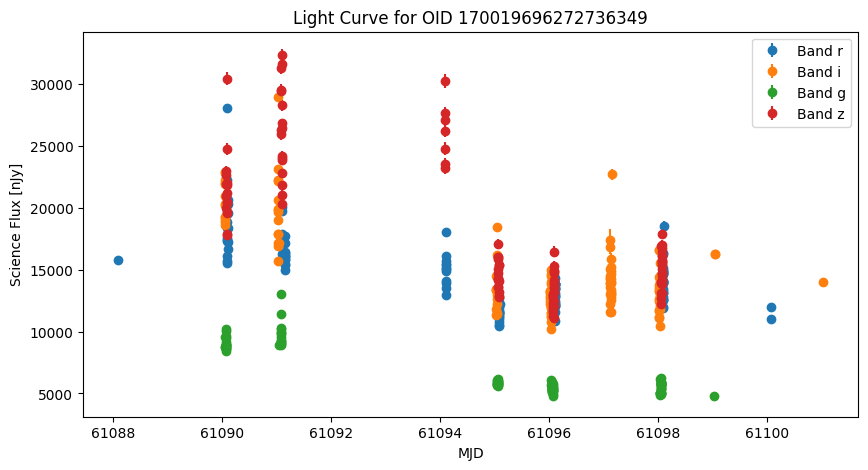

In [14]:
band_map = {
    6: 'u',
    1: 'g',
    2: 'r',
    3: 'i',
    4: 'z',
    5: 'y',
}

for oid in df_aux.oid.unique():
    df_oid = df_aux[df_aux.oid == oid].copy()
    bands = df_oid.band.unique()

    fig, ax = plt.subplots(figsize=(10, 5))
    for band in bands:
        subset = df_oid[df_oid.band == band]
        ax.errorbar(
            subset.mjd,
            subset.scienceflux,
            yerr=subset.sciencefluxerr,
            fmt='o',
            label=f'Band {band_map[band]}',
        )

    ax.set_title(f'Light Curve for OID {oid}')
    ax.set_xlabel('MJD')
    ax.set_ylabel(r'Science Flux [nJy]')
    ax.legend()
    plt.show()

    break

In [18]:
all_df_obj_ztf = pd.DataFrame()
for oid in df_aux.oid.unique():
    df_oid = df_aux[df_aux.oid == oid].copy()
    ra, dec = df_oid.ra.values[0], df_oid.dec.values[0]

    df_obj_ztf = alerce_client.query_objects(
    survey='ztf',
    ra=ra,
    dec=dec,
    radius=1.5,
    )

    if df_obj_ztf.size > 0:
        all_df_obj_ztf = pd.concat([all_df_obj_ztf, df_obj_ztf])
        all_df_obj_ztf['lsst_oid'] = oid

/tmp/ipykernel_812/4139855144.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_df_obj_ztf = pd.concat([all_df_obj_ztf, df_obj_ztf])
/tmp/ipykernel_812/4139855144.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_df_obj_ztf = pd.concat([all_df_obj_ztf, df_obj_ztf])
/tmp/ipykernel_812/4139855144.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determ

In [19]:
all_df_obj_ztf.reset_index(drop=True,inplace=True)
all_df_obj_ztf

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr,lsst_oid
0,ZTF24aabcdfg,4,1093,58900.255023,60317.538183,True,False,2,NaN,NaN,...,21.113854,150.112758,3.374528,0.060208,0.060104,None,None,None,23.12.25,313928193955332182
1,ZTF19aammewe,2,57,58503.307315,58556.210857,True,True,1,NaN,NaN,...,0.000000,150.529170,3.057530,NaN,NaN,None,None,None,corr_bulk_0.0.1,313928193955332182
2,ZTF19aamgnns,149,1421,58503.307315,60681.399618,True,False,93,NaN,NaN,...,2125.188762,150.529333,3.057711,0.007794,0.007783,None,None,None,26.0.1,313928193955332182
3,ZTF20aazbbqo,216,1568,58503.307315,61021.362882,True,False,138,NaN,NaN,...,2066.178322,150.529433,3.057800,0.006557,0.006548,None,None,None,27.5.7a32.dev1,313928193955332182
4,ZTF26aacextk,23,2217,61058.439630,61078.519271,False,False,6,NaN,NaN,...,18.958461,187.020241,6.967839,0.030032,0.029810,None,None,None,27.5.7a32.dev1,313928193955332182
5,ZTF19aaapcyh,53,1129,58114.500000,59909.500000,True,False,19,1.213030,0.647604,...,1337.189445,185.020057,7.815280,0.000099,0.000094,None,None,None,1.1.6,313928193955332182
6,ZTF18aaqjmvc,7,2445,58243.169838,59996.407072,False,False,1,NaN,NaN,...,0.000000,187.404343,7.932741,NaN,NaN,None,None,None,0.0.0,313928193955332182
7,ZTF18aaqjndv,25,4708,58114.520220,61085.440718,True,False,2,NaN,NaN,...,600.200625,185.054040,8.354250,0.046455,0.045962,None,None,None,27.5.7a32.dev1,313928193955332182
8,ZTF18aaqjmvc,7,2445,58243.169838,59996.407072,False,False,1,NaN,NaN,...,0.000000,187.404343,7.932741,NaN,NaN,None,None,None,0.0.0,313928193955332182
9,ZTF23abqmrag,3,2940,59310.250000,60260.500000,True,False,1,NaN,NaN,...,0.000000,187.375791,7.993310,NaN,NaN,None,None,None,1.2.1,313928193955332182


In [20]:
all_df_obj_ztf.lsst_oid

,lsst_oid
0,313928193955332182
1,313928193955332182
2,313928193955332182
3,313928193955332182
4,313928193955332182
5,313928193955332182
6,313928193955332182
7,313928193955332182
8,313928193955332182
9,313928193955332182


In [21]:
idx = np.random.randint(0, len(all_df_obj_ztf))
print(idx)

df_dets_ztf = alerce_client.query_detections(
    oid=all_df_obj_ztf.oid.values[idx],
    survey='ztf',
    format='pandas'
)

df_dets_lsst = alerce_client.query_detections(
    oid=all_df_obj_ztf.lsst_oid.values[idx],
    survey='lsst',
    format='pandas'
)

#df_dets_ztf, df_dets_lsst

1


In [22]:
print(list(df_dets_lsst.columns))

['band', 'mjd', 'survey_id', 'ra', 'dec', 'oid', 'measurement_id', 'parentDiaSourceId', 'diaObjectId', 'psfFlux', 'psfFluxErr', 'psfFlux_flag', 'psfFlux_flag_edge', 'psfFlux_flag_noGoodPixels', 'scienceFlux', 'scienceFluxErr', 'has_stamp', 'visit', 'detector', 'ssObjectId', 'raErr', 'decErr', 'ra_dec_Cov', 'x', 'xErr', 'y', 'yErr', 'centroid_flag', 'apFlux', 'apFluxErr', 'apFlux_flag', 'apFlux_flag_apertureTruncated', 'isNegative', 'snr', 'psfLnL', 'psfChi2', 'psfNdata', 'trailFlux', 'trailFluxErr', 'trailRa', 'trailRaErr', 'trailDec', 'trailDecErr', 'trailLength', 'trailLengthErr', 'trailAngle', 'trailAngleErr', 'trailChi2', 'trailNdata', 'trail_flag_edge', 'dipoleMeanFlux', 'dipoleMeanFluxErr', 'dipoleFluxDiff', 'dipoleFluxDiffErr', 'dipoleLength', 'dipoleAngle', 'dipoleChi2', 'dipoleNdata', 'forced_PsfFlux_flag', 'forced_PsfFlux_flag_edge', 'forced_PsfFlux_flag_noGoodPixels', 'templateFlux', 'templateFluxErr', 'ixx', 'iyy', 'ixy', 'ixxPSF', 'iyyPSF', 'ixyPSF', 'shape_flag', 'shape_f

In [23]:
def fluxnjy2mag(flux):
    return 31.4 - 2.5 * np.log10(flux)

def flux_err_2_mag_err(flux_err, flux):
    return (2.5 * flux_err) / (np.log(10.0) * flux)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


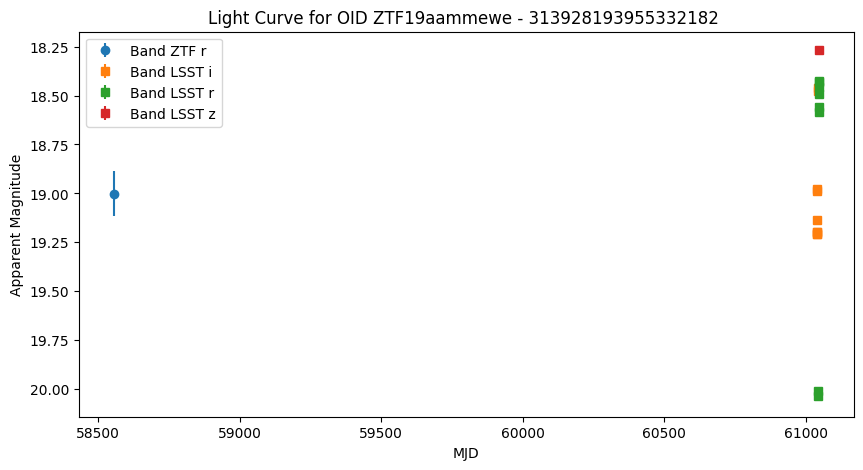

In [24]:
band_map_ztf = {
    1: 'g',
    2: 'r',
}

band_map_lsst = {
    1: 'g',
    2: 'r',
    3: 'i',
    4: 'z',
    5: 'y',
    6: 'u',
}

fig, ax = plt.subplots(figsize=(10, 5))
for band in df_dets_ztf.fid.unique():
    subset = df_dets_ztf[df_dets_ztf.fid == band]
    ax.errorbar(
        subset.mjd,
        subset.magpsf,
        yerr=subset.sigmapsf,
        fmt='o',
        label=f'Band ZTF {band_map_ztf[band]}',
    )

for band in df_dets_lsst.band.unique():
    subset = df_dets_lsst[df_dets_lsst.band == band]
    ax.errorbar(
        subset.mjd,
        fluxnjy2mag(subset.psfFlux),
        yerr=np.abs(flux_err_2_mag_err(subset.psfFluxErr,subset.psfFlux)),
        fmt='s',
        label=f'Band LSST {band_map_lsst[band]}',
    )

ax.set_title(f'Light Curve for OID {all_df_obj_ztf.oid.values[idx]} - {all_df_obj_ztf.lsst_oid.values[idx]} ')
ax.set_xlabel('MJD')
ax.set_ylabel(r'Apparent Magnitude')
ax.invert_yaxis()
ax.legend()
plt.show()

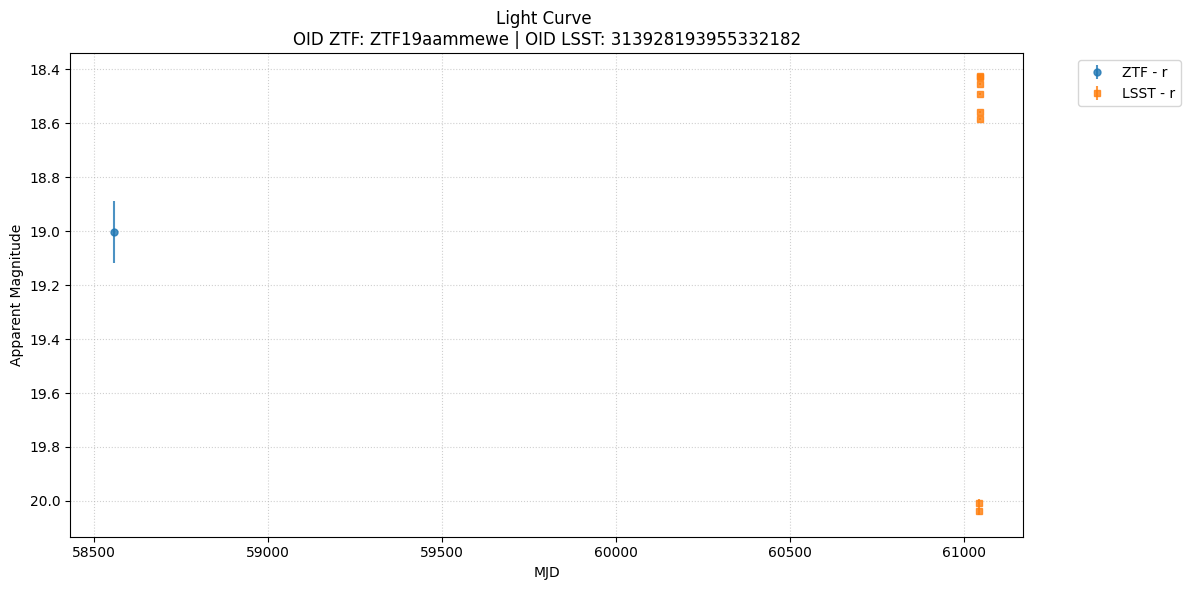

In [25]:
# 1. Definir mapeos invertidos para encontrar qué bandas coinciden por nombre
# ZTF: 1:'g', 2:'r' | LSST: 1:'g', 2:'r', 3:'i', etc.
common_band_names = set(band_map_ztf.values()) & set(band_map_lsst.values())

fig, ax = plt.subplots(figsize=(12, 6))

# --- GRAFICAR ZTF ---
# Filtramos el DataFrame para que solo contenga fids cuyo nombre de banda esté en la intersección
for fid, subset in df_dets_ztf.groupby('fid'):
    band_name = band_map_ztf.get(fid)
    if band_name in common_band_names:
        ax.errorbar(
            subset.mjd,
            subset.magpsf,
            yerr=subset.sigmapsf,
            fmt='o',
            markersize=5,
            label=f'ZTF - {band_name}',
            alpha=0.8
        )

# --- GRAFICAR LSST ---
# Filtramos para que la banda de LSST también esté en la intersección
for band_id, subset in df_dets_lsst.groupby('band'):
    band_name = band_map_lsst.get(band_id)
    if band_name in common_band_names:
        ax.errorbar(
            subset.mjd,
            fluxnjy2mag(subset.psfFlux),
            yerr=np.abs(flux_err_2_mag_err(subset.psfFluxErr, subset.psfFlux)),
            fmt='s', # Cuadrados para diferenciar de ZTF
            markersize=5,
            label=f'LSST - {band_name}',
            alpha=0.8
        )

# --- CONFIGURACIÓN DE EJES ---
ax.set_title(f'Light Curve \nOID ZTF: {all_df_obj_ztf.oid.values[idx]} | OID LSST: {all_df_obj_ztf.lsst_oid.values[idx]}')
ax.set_xlabel('MJD')
ax.set_ylabel('Apparent Magnitude')

ax.invert_yaxis() # Magnitudes invertidas
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera para no tapar puntos
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [32]:
df_objs = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'lastmjd_']
df_objs.drop(columns=[c for c in cols if c in df_objs.columns], inplace=True)

print("Número de candidatos LSST:", len(df_objs))
display(df_objs.head())
df_objs.to_csv("lsst_sn_candidates.csv", index=False)

Número de candidatos LSST: 12122


,oid,sid,measurement_id,mjd,ra,dec,band,created_date,measurement_id_,parentdiasourceid,...,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,created_date_
0,170019696272736349,1,170019696272736349,61088.098045,61.497105,-49.245784,2,2026-02-19,170019696272736349,0,...,False,False,False,False,False,False,False,False,True,2026-02-19
1,170019696272736349,1,170028485813731360,61090.048021,61.497129,-49.245774,3,2026-02-19,170028485813731360,0,...,False,False,False,False,False,False,False,False,True,2026-02-19
2,170019696272736349,1,170028486077972623,61090.053112,61.497117,-49.245780,3,2026-02-19,170028486077972623,0,...,False,False,False,False,False,False,False,False,True,2026-02-19
3,170019696272736349,1,170028486452838484,61090.054409,61.497095,-49.245780,3,2026-02-19,170028486452838484,0,...,False,False,False,False,False,False,False,False,True,2026-02-19
4,170019696272736349,1,170028486613794895,61090.054840,61.497109,-49.245785,3,2026-02-19,170028486613794895,0,...,False,False,False,False,False,False,False,False,True,2026-02-19


In [8]:
from google.colab import files
files.download("lsst_sn_candidates.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# LIGHT CURVES LSST CANDIDATES

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle("df_sn_lsst.pkl")

print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())
print("Valores únicos en band:", sorted(df["band"].unique()))

Shape: (4056, 7)
Columnas: ['oid', 'band', 'mjd', 'psfFlux', 'psfFluxErr', 'ra', 'dec']
Valores únicos en band: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [27]:

#ajuste g
if len(g) > deg:
    x = g["mjd"].values
    y = g["magpsf"].values

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    if len(x) > deg:
        p = np.polyfit(x, y, deg)
        poly = np.poly1d(p)

        xfit = np.linspace(x.min(), x.max(), 500)
        yfit = poly(xfit)

        plt.plot(
            xfit, yfit,
            color="green",
            label="g polynomial fit",
            zorder=1
        )

        i = np.argmin(yfit)   # menor magnitud = mayor brillo
        x_max_g = xfit[i]
        y_max_g = yfit[i]

        plt.scatter(
            x_max_g, y_max_g,
            color="black",
            marker="x",
            s=140,
            zorder=5,
            label="maximum brightness"
        )

#ajuste r
if len(r) > deg:
    x = r["mjd"].values
    y = r["magpsf"].values

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    if len(x) > deg:
        p = np.polyfit(x, y, deg)
        poly = np.poly1d(p)

        xfit = np.linspace(x.min(), x.max(), 500)
        yfit = poly(xfit)

        plt.plot(
            xfit, yfit,
            color="red",
            label="r polynomial fit",
            zorder=1
        )

        i = np.argmin(yfit)
        x_max_r = xfit[i]
        y_max_r = yfit[i]

        plt.scatter(
            x_max_r, y_max_r,
            color="black",
            marker="x",
            s=140,
            zorder=5
        )


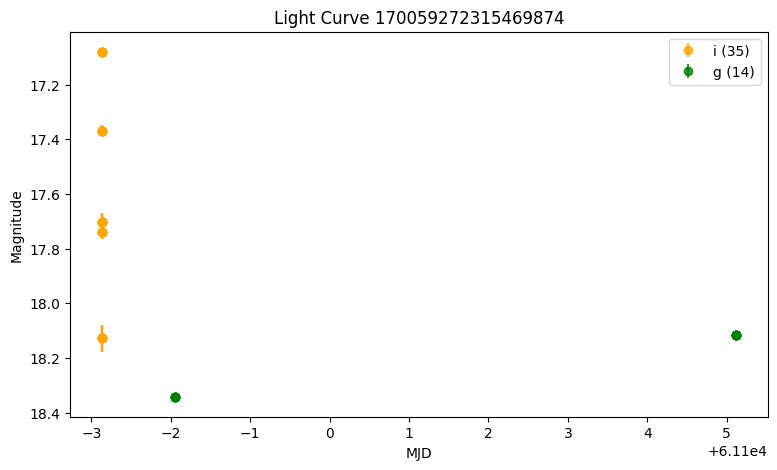

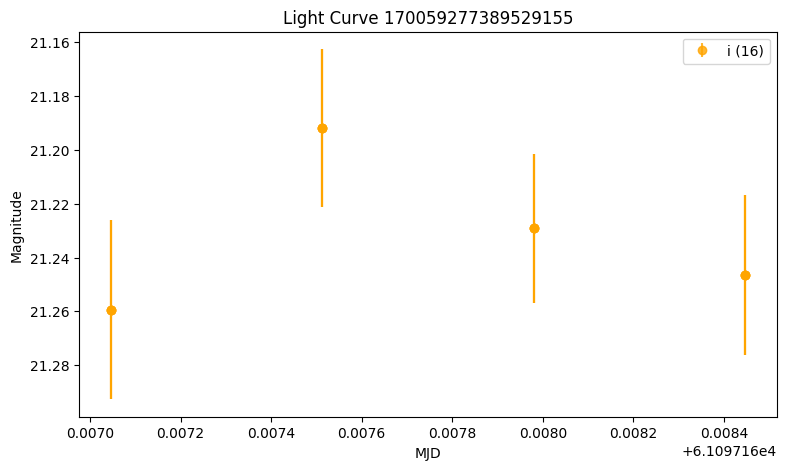

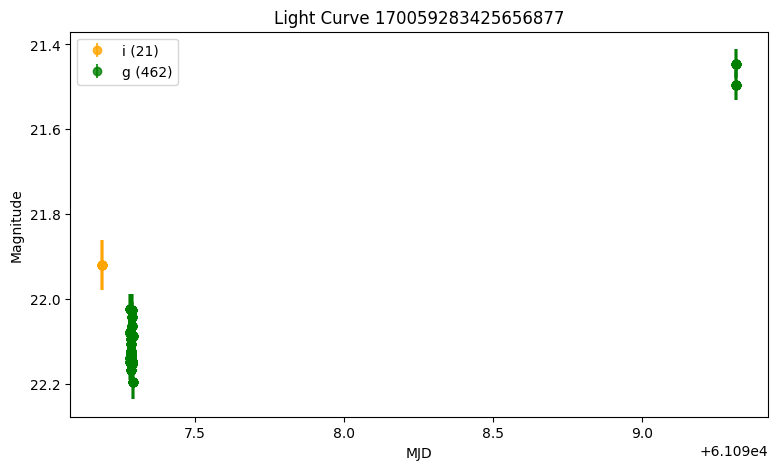

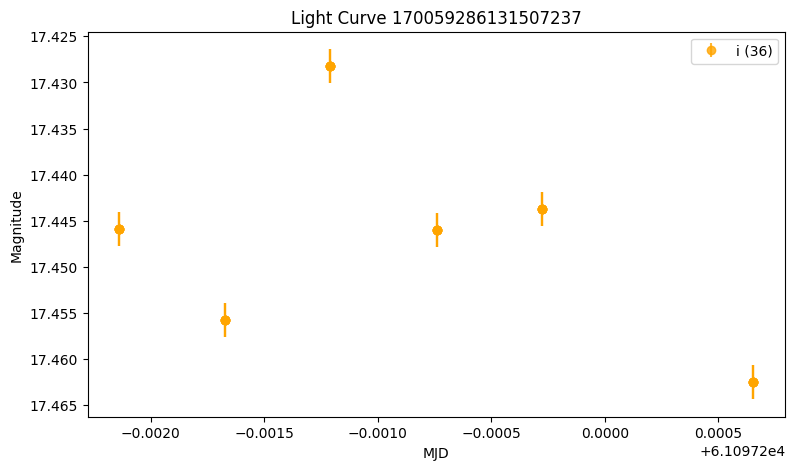

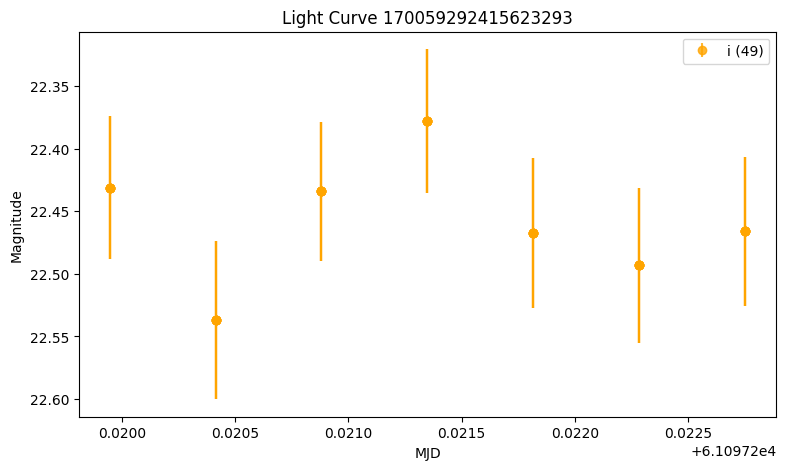

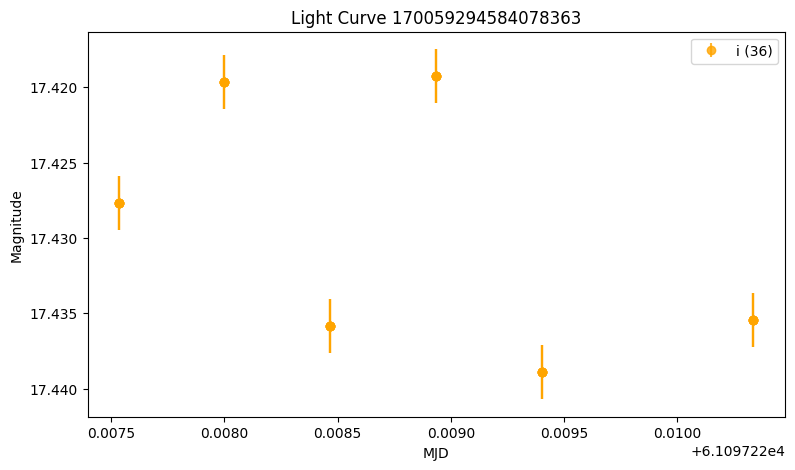

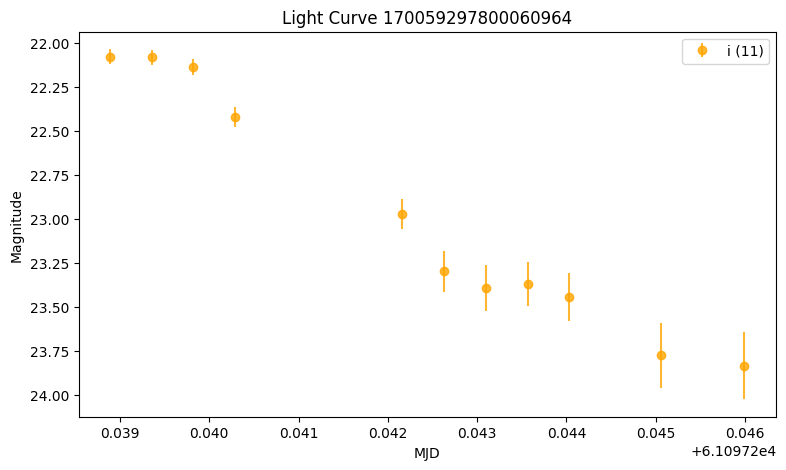

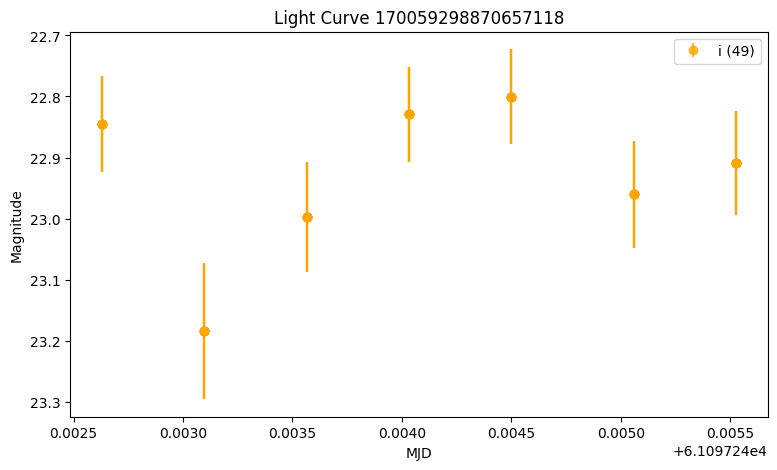

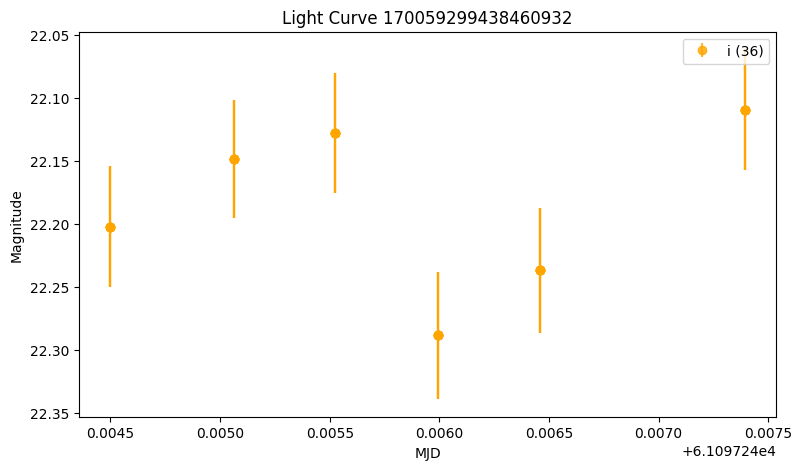

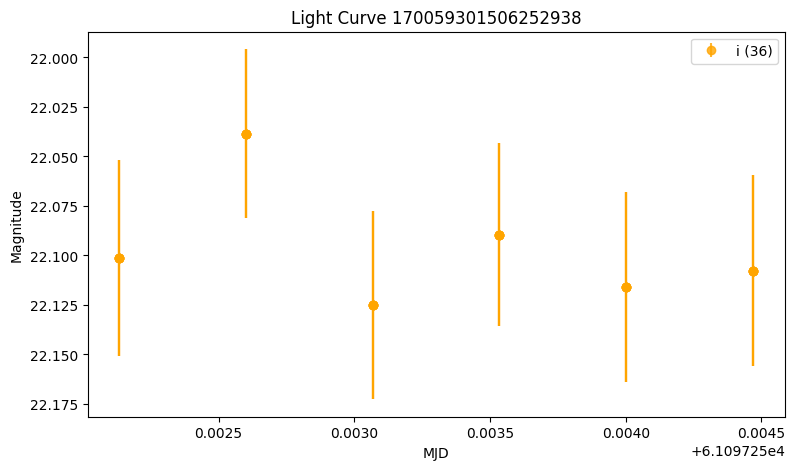

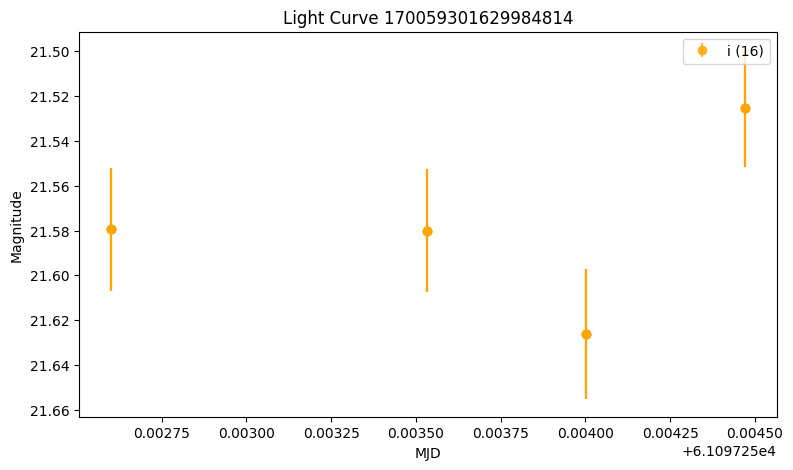

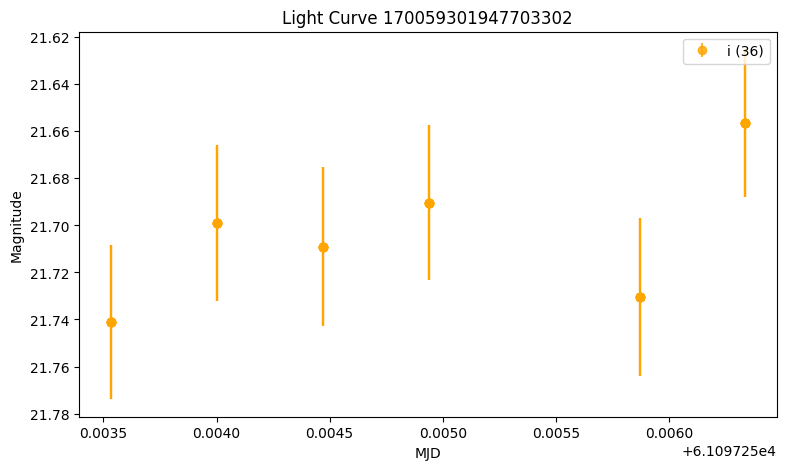

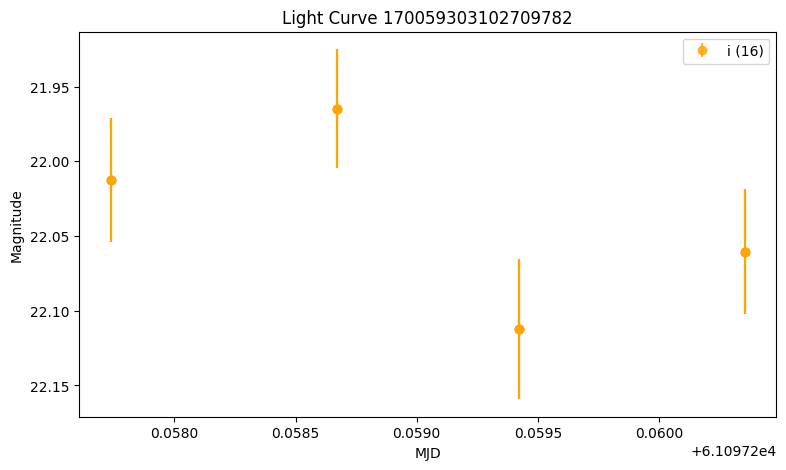

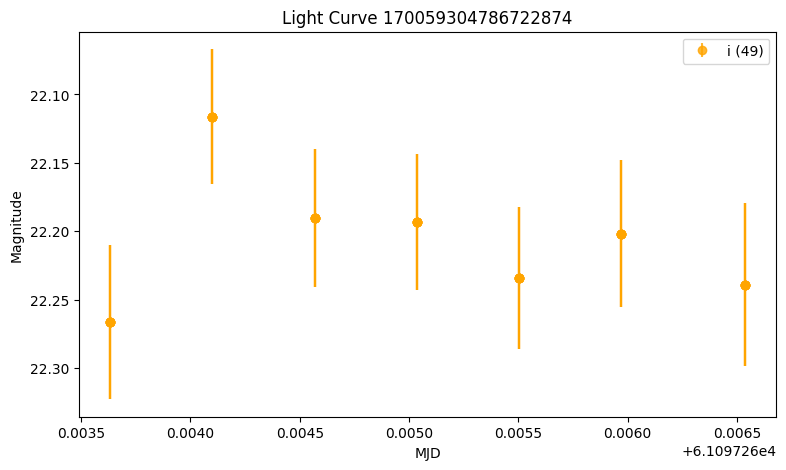

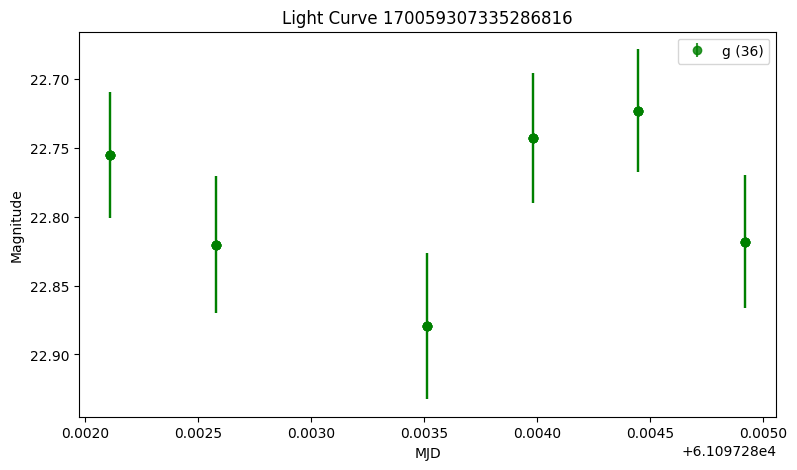

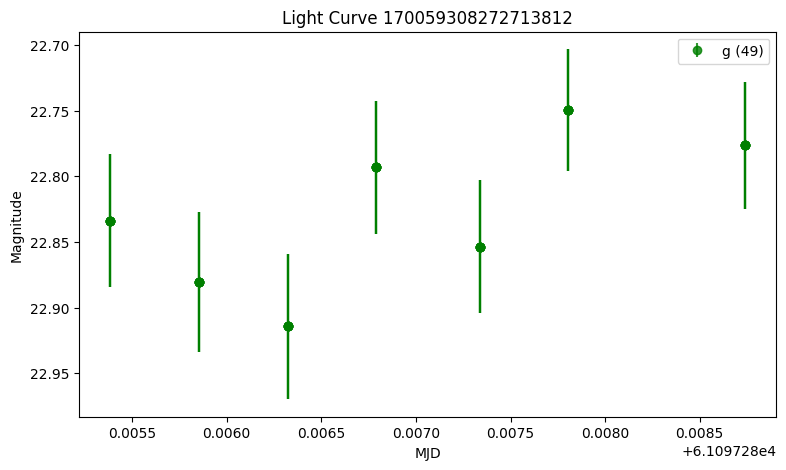

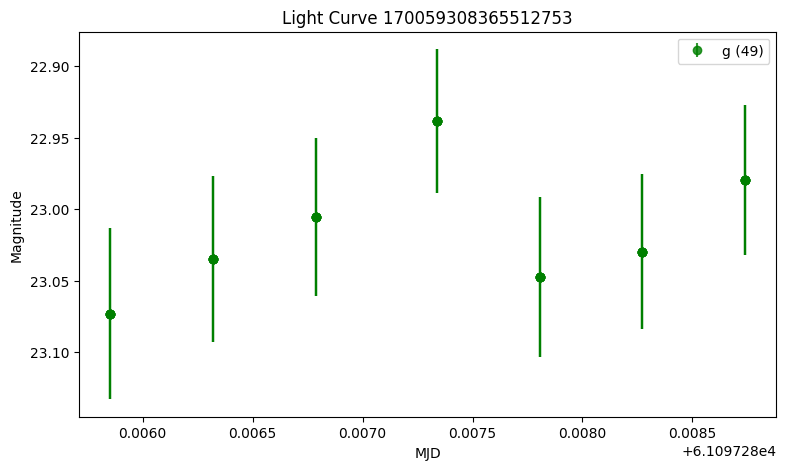

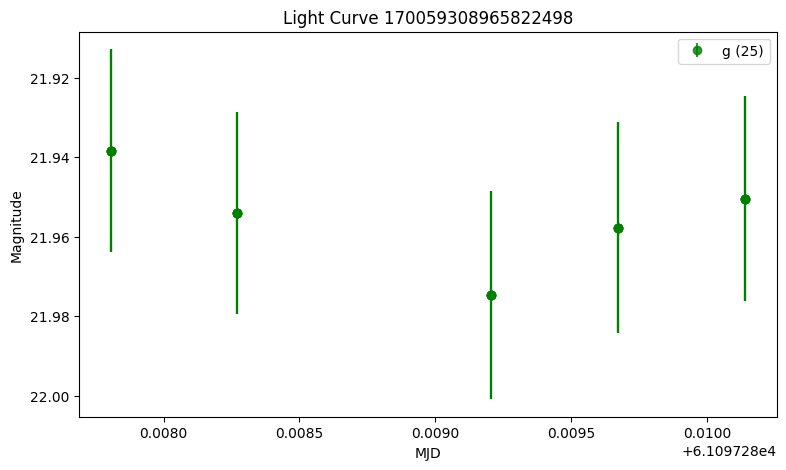

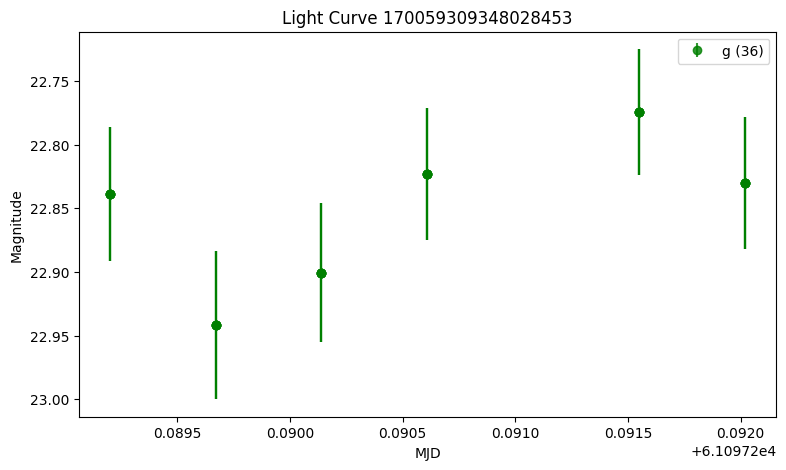

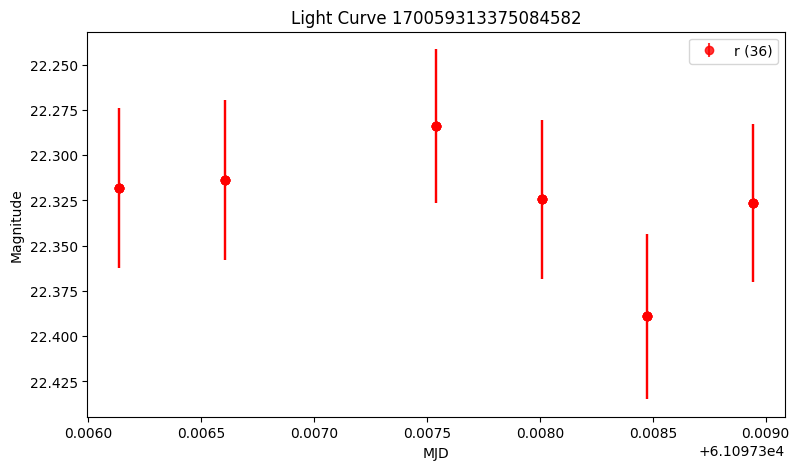

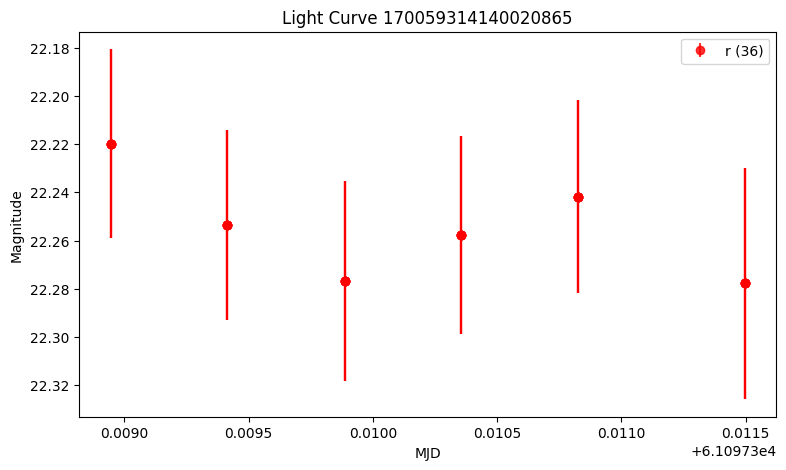

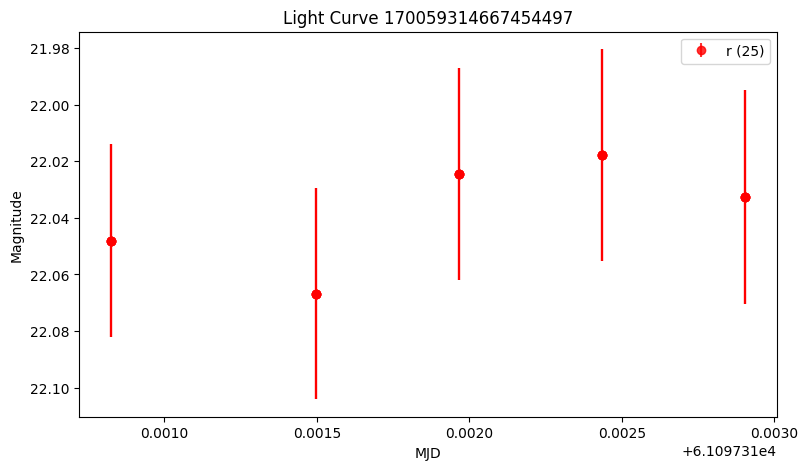

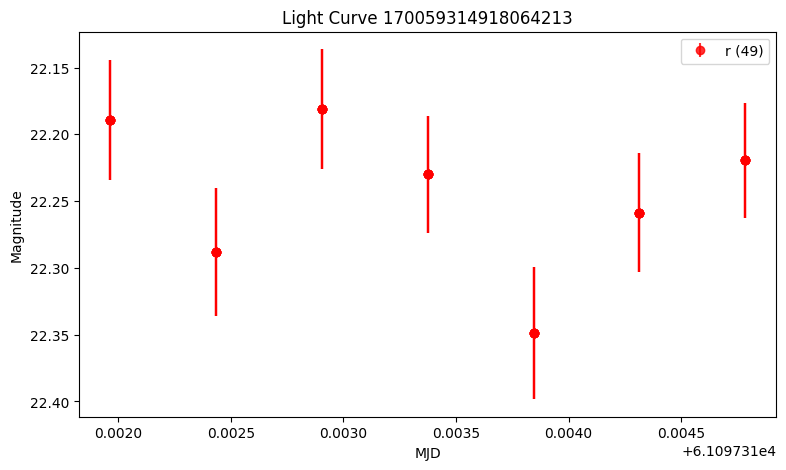

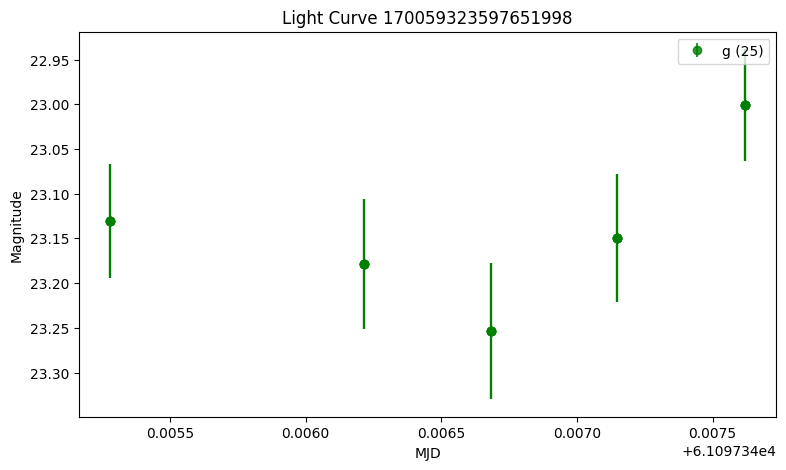

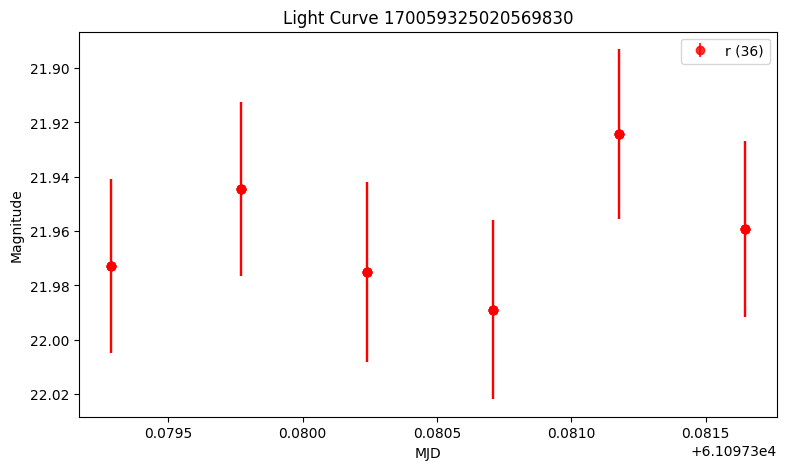

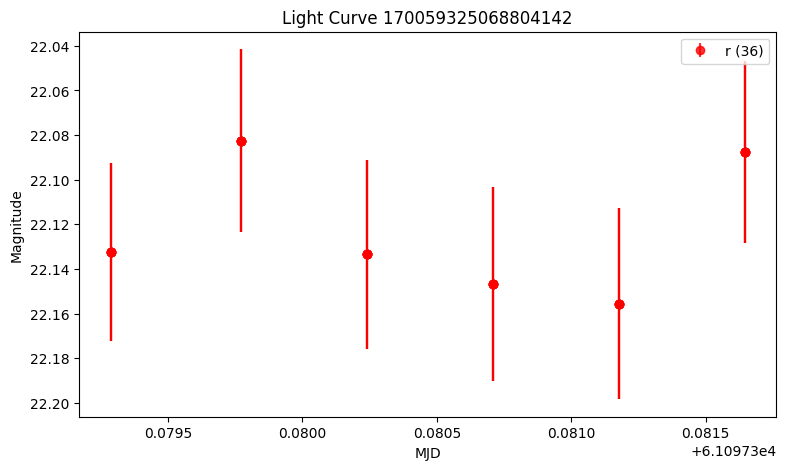

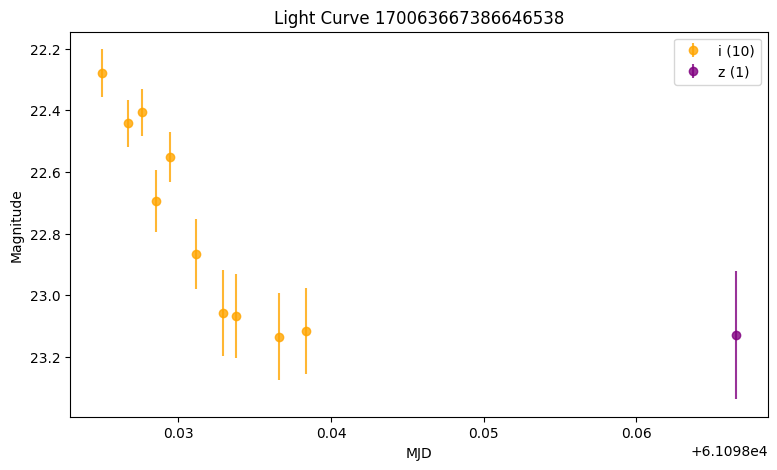

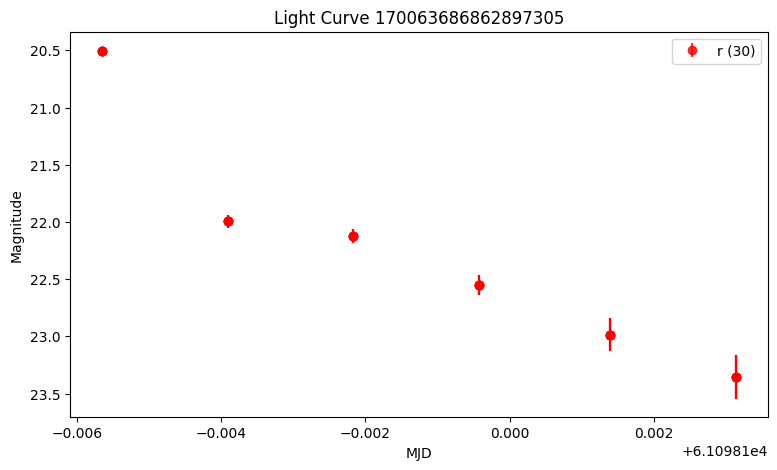

Objetos que cumplen condición: 28


In [28]:

# mapa de bandas
band_map = {
    1: "g",
    2: "r",
    3: "i",
    4: "z",
    5: "y",
    6: "u"
}

df["band_name"] = df["band"].map(band_map)

# convertir flujo → magnitud
ZP = 31.4

df = df[df["psfFlux"] > 0].copy()

df["magpsf"] = -2.5 * np.log10(df["psfFlux"]) + ZP
df["sigmapsf"] = (2.5 / np.log(10)) * (df["psfFluxErr"] / df["psfFlux"])

df = df[np.isfinite(df["magpsf"])]

colors = {
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
    "y": "brown",
    "u": "blue"
}

count_plotted = 0

for oid, det in df.groupby("oid"):

    # contar puntos por banda
    counts = det["band_name"].value_counts()

    # condición: alguna banda con >=7 puntos
    if not (counts >= 10).any():
        continue

    det = det.sort_values("mjd")

    plt.figure(figsize=(9,5))

    for band in det["band_name"].unique():

        d = det[det["band_name"] == band]

        plt.errorbar(
            d["mjd"],
            d["magpsf"],
            yerr=d["sigmapsf"],
            fmt="o",
            color=colors.get(band, "black"),
            label=f"{band} ({len(d)})",
            alpha=0.8
        )

    plt.gca().invert_yaxis()

    plt.xlabel("MJD")
    plt.ylabel("Magnitude")

    plt.title(f"Light Curve {oid}")

    plt.legend()

    plt.show()

    count_plotted += 1

print("Objetos que cumplen condición:", count_plotted)